In [1]:
# Import required libraries
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load California Housing Dataset
housing = fetch_california_housing()

# Features (X) and Target (y)
X = housing.data
y = housing.target

# Split dataset into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Model Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print Results
print("Model Performance")
print("-" * 30)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)

# Display Model Coefficients
coefficients = pd.DataFrame({
    "Feature": housing.feature_names,
    "Coefficient": model.coef_
})

print("\nFeature Coefficients:")
print(coefficients)

# Compare Actual vs Predicted Values
results = pd.DataFrame({
    "Actual": y_test[:10],
    "Predicted": y_pred[:10]
})

print("\nActual vs Predicted Values:")
print(results)

Model Performance
------------------------------
Mean Absolute Error (MAE): 0.5332001304956989
Mean Squared Error (MSE): 0.5558915986952425
Root Mean Squared Error (RMSE): 0.7455813830127751
R2 Score: 0.5757877060324521

Feature Coefficients:
      Feature  Coefficient
0      MedInc     0.448675
1    HouseAge     0.009724
2    AveRooms    -0.123323
3   AveBedrms     0.783145
4  Population    -0.000002
5    AveOccup    -0.003526
6    Latitude    -0.419792
7   Longitude    -0.433708

Actual vs Predicted Values:
    Actual  Predicted
0  0.47700   0.719123
1  0.45800   1.764017
2  5.00001   2.709659
3  2.18600   2.838926
4  2.78000   2.604657
5  1.58700   2.011754
6  1.98200   2.645500
7  1.57500   2.168755
8  3.40000   2.740746
9  4.46600   3.915615


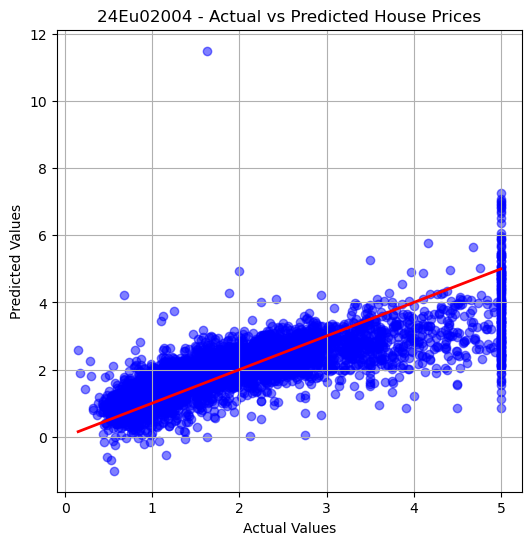

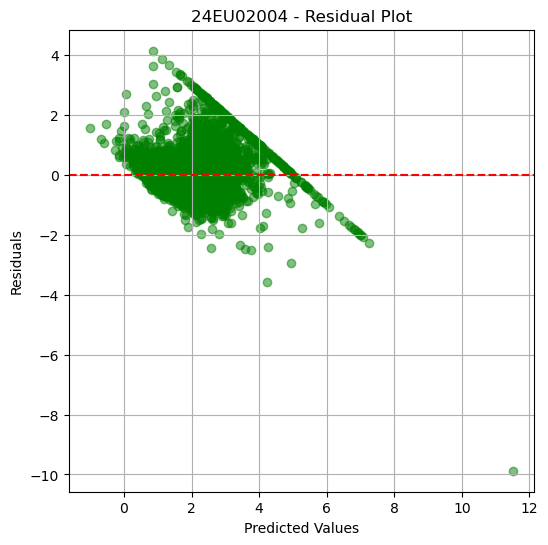

In [3]:
import matplotlib.pyplot as plt

# -------------------------------
# Actual vs Predicted Scatter Plot
# -------------------------------
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2)

plt.title("24Eu02004 - Actual vs Predicted House Prices")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.grid(True)
plt.show()

# -------------------------------
# Residual Plot
# -------------------------------
residuals = y_test - y_pred

plt.figure(figsize=(6,6))
plt.scatter(y_pred, residuals, color='green', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')

plt.title("24EU02004 - Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.grid(True)
plt.show()